In [1]:
# pip install langchain langgraph langsmith langchain_groq langchain_community

In [2]:
groq_api_key = "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"

In [3]:
from langchain_groq import ChatGroq

c:\Users\Raviteja\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
llm = ChatGroq(groq_api_key = groq_api_key, model_name = "llama-3.3-70b-versatile")

In [5]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph,START,END 

In [6]:
class State(TypedDict):
    messages:Annotated[list,add_messages] 
    
graph_builder=StateGraph(State)

In [7]:
graph_builder

In [8]:
def chatbot(state:State):
    return{"messages":llm.invoke(state['messages'])}

In [9]:
graph_builder.add_node('chatbot',chatbot)

In [10]:
graph_builder

In [11]:
graph_builder.add_edge(START, 'chatbot')
graph_builder.add_edge('chatbot', END)

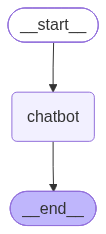

In [12]:
graph_builder.compile()

In [13]:
graph = graph_builder.compile()

In [ ]:
while True:
    user_input=input("user:")
    if user_input.lower() in ['quit','q']:
        print('Good Bye, thank you using LangGrpah Framework create by Ravi Teja')
        break 
    for event in graph.stream({'messages':('user', user_input)}):
        print(event.values())
        for value in event.values():
            print(value['messages'])
            print('Assistant:',value['messages'].content)

dict_values([{'messages': AIMessage(content="It seems like you didn't type anything. Please feel free to ask me anything or start a conversation. I'm here to help!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 35, 'total_tokens': 63, 'completion_time': 0.080215607, 'completion_tokens_details': None, 'prompt_time': 0.002692188, 'prompt_tokens_details': None, 'queue_time': 0.161907621, 'total_time': 0.082907795}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fdb5b-4b6e-7973-9a50-74700e568500-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 35, 'output_tokens': 28, 'total_tokens': 63})}])
content="It seems like you didn't type anything. Please feel free to ask me anything or start a conversation. I'm here to help!" additional_kwargs={} response_metadata={'token_usa